# MD-GRTN Phase 1 — PEMS08
**Changes:** `d_model=128` | `n_heads=4` | `num_layers=5` | `gru_layers=5` | `seq_len=12` | `batch_size=32` | 2-seq MDAF | GAT+GRU | Huber loss | AdamW | **BackNet pre-training** | **temporal position encoding** | noise augmentation | distance adjacency

**Architecture:** MDAF(BackNet pretrained) → MGRC(GAT+GRU ×5) → STFormer(spatial+temporal pos enc) ×5 → Prediction

**VRAM estimate:** ~11 GB / 15 GB T4  ✓


In [1]:
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════
# SEED — fixes ALL randomness across sessions
# Run this first, every single session
# ══════════════════════════════════════════════════
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f'Seed set: {seed} — results reproducible across sessions ✓')

set_seed()

print('PyTorch :', torch.__version__)
print('CUDA    :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))
    print('VRAM    :', round(torch.cuda.get_device_properties(0).total_memory/1e9,1), 'GB')

Seed set: 42 — results reproducible across sessions ✓
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


In [2]:
# ══════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════
class Config:
    # data
    data_path   = "/kaggle/input/datasets/piyusharma17/pems-08/PEMS08.npz"
    num_nodes   = 170
    in_features = 3
    seq_len     = 12    # paper uses 12 (60 min history)
    pred_len    = 12
    feature_idx = 0
    hour_offset = 12    # 1 hr ago = 12 × 5-min steps
    noise_std   = 10.0  # Gaussian noise σ added to inputs (paper §V-A)
    train_ratio = 0.7   # paper 7:1:2
    val_ratio   = 0.1

    # model — T4-safe
    d_model    = 128    # d_head = 32 with n_heads=4
    n_heads    = 4
    num_layers = 5      # STFormer layers
    gat_layers = 3      # pure GAT layers in MGRC (no GRU overhead, fits T4)
    dropout    = 0.05

    # BackNet pre-training (paper Algorithm 1, lines 1-6)
    pretrain_epochs = 20
    pretrain_lr     = 1e-3
    pretrain_path   = "backnet_pretrained.pt"

    # main training
    batch_size   = 32
    lr           = 5e-4
    epochs       = 100
    patience     = 15
    weight_decay = 1e-4

    # checkpoint
    ckpt_path = "mdgrtn_phase1_ckpt.pt"
    best_path = "mdgrtn_phase1_best.pt"

cfg    = Config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Config ready | d_model={cfg.d_model} | n_heads={cfg.n_heads} | "
      f"num_layers={cfg.num_layers} | gat_layers={cfg.gat_layers} | device={device}")


Config ready | d_model=128 | n_heads=4 | num_layers=5 | gat_layers=3 | device=cuda


In [3]:
def load_pems08(cfg):
    raw  = np.load(cfg.data_path)
    print("Keys:", list(raw.keys()))
    data = raw["data"].astype(np.float32)   # (T, N, F)
    T, N, F = data.shape
    print(f"Shape: {data.shape}")

    # Z-score on CLEAN data — per-sensor stats (axis=0 over time)
    # shape: (N, F) — one mean/std per sensor per feature
    mean_np = data.mean(axis=0)          # (N, F)
    std_np  = data.std (axis=0) + 1e-8  # (N, F)
    data_clean = (data - mean_np[None]) / std_np[None]   # (T, N, F)

    # Noise σ in normalised space — use mean std across sensors for feature 0
    feat_std_raw   = std_np[:, cfg.feature_idx].mean()   # scalar
    norm_noise_std = cfg.noise_std / (feat_std_raw + 1e-8)
    print(f"Raw noise σ={cfg.noise_std:.1f} → normalised σ≈{norm_noise_std:.4f}")

    # Distance adjacency (paper Eq.11): Gaussian kernel
    A_dist = None
    for key in ("adjacency_matrix", "adj_mx", "adj"):
        if key in raw:
            A_dist = raw[key].astype(np.float32)
            print(f"Adjacency loaded from \"{key}\"")
            break
    if A_dist is None:
        print("No adjacency — using identity")
        A_dist = np.eye(N, dtype=np.float32)

    nonzero = A_dist[A_dist > 0]
    sigma   = nonzero.std() if len(nonzero) > 0 else 1.0
    A_dist  = np.exp(-(A_dist ** 2) / (sigma ** 2 + 1e-8))
    np.fill_diagonal(A_dist, 0.0)
    A_dist  = A_dist / (A_dist.sum(axis=1, keepdims=True) + 1e-8)

    # mean_np, std_np shape: (N, F) — per sensor, used for denormalisation
    return data_clean, mean_np, std_np, A_dist, norm_noise_std


class TrafficDataset(Dataset):
    """
    Returns (x_rec_noisy, x_hour_noisy, y_clean).
    noise_std=0 → clean inputs (val/test).
    """
    def __init__(self, data_clean, seq_len, pred_len, feature_idx,
                 hour_offset=12, noise_std=0.0,
                 split_start=0, split_end=None, training=False):
        self.data        = data_clean
        self.seq_len     = seq_len
        self.pred_len    = pred_len
        self.feat_idx    = feature_idx
        self.hour_offset = hour_offset
        self.noise_std   = noise_std
        self.training    = training
        T = len(data_clean)
        split_end = split_end if split_end is not None else T
        first_i   = max(split_start, hour_offset)
        # last valid i: i + seq_len + pred_len - 1 < split_end
        last_i    = split_end - seq_len - pred_len + 1
        assert last_i > first_i, f"Split too small: first={first_i} last={last_i}"
        self.indices = list(range(first_i, last_i))

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx):
        i     = self.indices[idx]
        rec   = self.data[i : i + self.seq_len].copy()
        hour  = self.data[i - self.hour_offset : i - self.hour_offset + self.seq_len].copy()
        y     = self.data[i + self.seq_len : i + self.seq_len + self.pred_len,
                          :, self.feat_idx].copy()
        if self.training and self.noise_std > 0:
            rec  += np.random.randn(*rec.shape ).astype(np.float32) * self.noise_std
            hour += np.random.randn(*hour.shape).astype(np.float32) * self.noise_std
        return (torch.from_numpy(rec),
                torch.from_numpy(hour),
                torch.from_numpy(y))


def build_dataloaders(cfg):
    set_seed()
    data_clean, mean_np, std_np, A_dist, norm_noise = load_pems08(cfg)
    T  = len(data_clean)
    t1 = int(T * cfg.train_ratio)
    t2 = int(T * (cfg.train_ratio + cfg.val_ratio))

    kw    = dict(batch_size=cfg.batch_size, num_workers=0, pin_memory=False)
    ds_kw = dict(seq_len=cfg.seq_len, pred_len=cfg.pred_len,
                 feature_idx=cfg.feature_idx, hour_offset=cfg.hour_offset,
                 noise_std=norm_noise, data_clean=data_clean)
    dl_tr = DataLoader(TrafficDataset(**ds_kw, split_start=0,  split_end=t1, training=True),  shuffle=True,  **kw)
    dl_va = DataLoader(TrafficDataset(**ds_kw, split_start=t1, split_end=t2, training=False), shuffle=False, **kw)
    dl_te = DataLoader(TrafficDataset(**ds_kw, split_start=t2, split_end=T,  training=False), shuffle=False, **kw)
    print(f"Train={len(dl_tr.dataset)} | Val={len(dl_va.dataset)} | Test={len(dl_te.dataset)}")
    return dl_tr, dl_va, dl_te, mean_np, std_np, A_dist, norm_noise

print("Data utilities ready.")


Data utilities ready.


In [4]:
class BackNet(nn.Module):
    """MD backward process: noisy → clean feature (paper Eq.4).
    Projects in_features → d_model with residual + LayerNorm."""
    def __init__(self, in_dim, d_model):
        super().__init__()
        self.proj = nn.Linear(in_dim, d_model)
        self.net  = nn.Sequential(
            nn.Linear(d_model, d_model * 2), nn.GELU(),
            nn.Linear(d_model * 2, d_model))
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x):                   # x: (B, S, N, in_dim)
        h = self.proj(x)                    # → (B, S, N, d_model)
        return self.norm(h + self.net(h))   # residual


class MultiHeadAttentionFusion(nn.Module):
    """MAF module (paper Eq. 5-9): cross-sequence attention fusion.
    Input seqs are already in d_model space (BackNet output)."""
    def __init__(self, d_model, n_heads, n_seqs=2):
        super().__init__()
        # Q/K/V projections per sequence (paper W^Q_k, W^K_k, W^V_k)
        self.q_projs = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(n_seqs)])
        self.k_projs = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(n_seqs)])
        self.v_projs = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(n_seqs)])
        self.attn    = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm    = nn.LayerNorm(d_model)
        self.fc_out  = nn.Linear(d_model * n_seqs, d_model)   # Concat+FC (paper Eq.9)

    def forward(self, seqs):
        # seqs: list of (B, S, N, d_model)
        B, S, N, d = seqs[0].shape
        heads = []
        for Wq, Wk, Wv, seq in zip(self.q_projs, self.k_projs, self.v_projs, seqs):
            f  = seq.reshape(B*S, N, d)
            q, k, v = Wq(f), Wk(f), Wv(f)
            r, _    = self.attn(q, k, v)
            heads.append(self.norm(f + r).reshape(B, S, N, d))
        return self.fc_out(torch.cat(heads, dim=-1))   # (B, S, N, d_model)


class MDModule(nn.Module):
    def __init__(self, in_features, d_model, n_seqs=2):
        super().__init__()
        self.backnets = nn.ModuleList([BackNet(in_features, d_model) for _ in range(n_seqs)])
    def forward(self, seqs):
        return [bn(s) for bn, s in zip(self.backnets, seqs)]


class MDAFModule(nn.Module):
    def __init__(self, in_features, d_model, n_heads, n_seqs=2):
        super().__init__()
        self.md  = MDModule(in_features, d_model, n_seqs)
        self.maf = MultiHeadAttentionFusion(d_model, n_heads, n_seqs)
    def forward(self, seqs):
        return self.maf(self.md(seqs))   # (B, S, N, d_model)

print("MDAF defined.")


MDAF defined.


In [5]:
class GraphAttention(nn.Module):
    """Multi-head GAT using the fused adjacency as an attention mask."""
    def __init__(self, in_dim, out_dim, n_heads=4, dropout=0.1):
        super().__init__()
        assert out_dim % n_heads == 0
        self.n_heads = n_heads
        self.d_head  = out_dim // n_heads
        self.W       = nn.Linear(in_dim, out_dim, bias=False)
        # per-head attention vectors (size = d_head each)
        self.a_src   = nn.Parameter(torch.randn(1, n_heads, 1, self.d_head))
        self.a_dst   = nn.Parameter(torch.randn(1, n_heads, 1, self.d_head))
        self.drop    = nn.Dropout(dropout)
        self.out     = nn.Linear(out_dim, out_dim)
        nn.init.xavier_uniform_(self.W.weight)

    def forward(self, x, A):
        # x: (B, N, in_dim)   A: (N, N)
        B, N, _ = x.shape
        h = self.W(x).reshape(B, N, self.n_heads, self.d_head)  # (B,N,H,d)
        h = h.permute(0, 2, 1, 3)                                # (B,H,N,d)
        # e_src[b,h,i,1] = (h[b,h,i,:] * a_src).sum(-1)
        e_src = (h * self.a_src).sum(-1, keepdim=True)           # (B,H,N,1)
        # e_dst[b,h,1,j] = (h[b,h,j,:] * a_dst).sum(-1)
        e_dst = (h * self.a_dst).sum(-1, keepdim=True)           # (B,H,N,1)
        # broadcast: (B,H,N,1) + (B,H,1,N) → (B,H,N,N)
        e = F.leaky_relu(e_src + e_dst.permute(0, 1, 3, 2), negative_slope=0.2)
        # mask non-edges
        mask  = (A == 0).unsqueeze(0).unsqueeze(0)               # (1,1,N,N)
        e     = e.masked_fill(mask, -1e9)
        alpha = self.drop(torch.softmax(e, dim=-1))               # (B,H,N,N)
        out   = (alpha @ h).permute(0, 2, 1, 3).reshape(B, N, -1)  # (B,N,out_dim)
        return self.out(out)


class GATLayer(nn.Module):
    """Single GAT layer with residual + LayerNorm.
    Applied independently to each timestep: (B,N,d) → (B,N,d).
    No GRU — temporal dependencies handled by STFormer."""
    def __init__(self, d_model, n_heads=4, dropout=0.1):
        super().__init__()
        self.gat  = GraphAttention(d_model, d_model, n_heads, dropout)
        self.norm = nn.LayerNorm(d_model)
        self.ff   = nn.Sequential(
            nn.Linear(d_model, d_model * 2), nn.GELU(),
            nn.Linear(d_model * 2, d_model))
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, A):
        # x: (B, N, d)   A: (N, N)
        x = self.norm (x + self.drop(self.gat(x, A)))   # GAT + residual
        x = self.norm2(x + self.drop(self.ff(x)))        # FFN + residual
        return x


class MGRCModule(nn.Module):
    """Pure stacked GAT (no GRU, no attention beyond GAT).
    Each layer: fused-adj GAT → residual → LayerNorm → FFN → residual → LayerNorm.
    Applied across all timesteps independently — temporal context from STFormer."""
    def __init__(self, in_dim, hidden_dim, num_nodes, num_layers=4, n_heads=4, dropout=0.1):
        super().__init__()
        # Dynamic adjacency embedding (paper Eq.10)
        self.emb      = nn.Parameter(torch.randn(num_nodes, hidden_dim))
        self.adj_conv = nn.Conv2d(2, 1, kernel_size=1)
        # Input projection if dims differ
        self.input_proj = nn.Linear(in_dim, hidden_dim) if in_dim != hidden_dim else nn.Identity()
        # Stacked GAT layers — all same dimension
        self.layers = nn.ModuleList([
            GATLayer(hidden_dim, n_heads, dropout) for _ in range(num_layers)])

    def get_fused_adj(self, A_dist):
        A_dyna  = torch.softmax(self.emb @ self.emb.T, dim=-1)
        stacked = torch.stack([A_dist, A_dyna], dim=0).unsqueeze(0)  # (1,2,N,N)
        A_F     = F.relu(self.adj_conv(stacked).squeeze(0).squeeze(0))
        return A_F / (A_F.sum(-1, keepdim=True) + 1e-8)

    def forward(self, x, A_dist):
        # x: (B, S, N, d)
        B, S, N, d = x.shape
        A_F = self.get_fused_adj(A_dist)              # (N, N)
        x   = self.input_proj(x)                       # (B, S, N, hidden)
        # Apply each GAT layer across all timesteps independently
        x_flat = x.reshape(B*S, N, -1)                # (B*S, N, d)
        for layer in self.layers:
            x_flat = layer(x_flat, A_F)
        return x_flat.reshape(B, S, N, -1)             # (B, S, N, d)

print("MGRC defined — pure stacked GAT (no GRU).")

MGRC defined — pure stacked GAT (no GRU).


In [6]:
class SpatialTransformerLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff    = nn.Sequential(nn.Linear(d_model, d_model*4), nn.GELU(),
                                   nn.Linear(d_model*4, d_model))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        B, S, N, d = x.shape
        f = x.reshape(B*S, N, d)
        h, _ = self.attn(f, f, f)
        h = self.norm1(f + self.drop(h))
        h = self.norm2(h + self.drop(self.ff(h)))
        return h.reshape(B, S, N, d)


class TemporalPositionEncoding(nn.Module):
    """Paper Eq.21: hourly + daily + weekly temporal embeddings per layer."""
    def __init__(self, d_model, seq_len, num_nodes):
        super().__init__()
        # Learnable weights for each time granularity (paper: W_hour, W_day, W_week)
        self.W_hour = nn.Parameter(torch.randn(num_nodes, 1) * 0.02)
        self.W_day  = nn.Parameter(torch.randn(num_nodes, 1) * 0.02)
        self.W_week = nn.Parameter(torch.randn(num_nodes, 1) * 0.02)
        # Fixed encodings: values in [1,60], [1,24], [1,7] (paper)
        t = torch.arange(seq_len).float()
        self.register_buffer("E_hour", (t % 12 + 1).unsqueeze(0))   # (1, S) hourly
        self.register_buffer("E_day",  (t % 24 + 1).unsqueeze(0))   # (1, S) daily
        self.register_buffer("E_week", (t % 7  + 1).unsqueeze(0))   # (1, S) weekly
        self.proj = nn.Linear(1, d_model)

    def forward(self, x):
        # x: (B, S, N, d)
        B, S, N, d = x.shape
        # (N,1) @ (1,S) → (N,S) → (1,S,N,1)
        enc  = (self.W_hour @ self.E_hour +
                self.W_day  @ self.E_day  +
                self.W_week @ self.E_week)         # (N, S)
        enc  = enc.T.unsqueeze(0).unsqueeze(-1)    # (1, S, N, 1)
        enc  = self.proj(enc)                      # (1, S, N, d)
        return x + enc


class TemporalTransformerLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout, seq_len, num_nodes):
        super().__init__()
        self.tpe   = TemporalPositionEncoding(d_model, seq_len, num_nodes)
        self.attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff    = nn.Sequential(nn.Linear(d_model, d_model*4), nn.GELU(),
                                   nn.Linear(d_model*4, d_model))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        x = self.tpe(x)                                        # temporal pos enc
        B, S, N, d = x.shape
        f = x.permute(0,2,1,3).reshape(B*N, S, d)
        h, _ = self.attn(f, f, f)
        h = self.norm1(f + self.drop(h))
        h = self.norm2(h + self.drop(self.ff(h)))
        return h.reshape(B, N, S, d).permute(0,2,1,3)

print("Transformer layers defined.")


Transformer layers defined.


In [7]:
class MDGRTN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        N, F, d = cfg.num_nodes, cfg.in_features, cfg.d_model
        L, h, dr = cfg.num_layers, cfg.n_heads, cfg.dropout
        P, S = cfg.pred_len, cfg.seq_len

        self.mdaf = MDAFModule(F, d, h, n_seqs=2)
        self.mgrc = MGRCModule(d, d, N, num_layers=cfg.gat_layers,
                               n_heads=h, dropout=dr)

        # Spatial position embedding (paper Eq.15: X + A·W_SPE)
        self.spatial_pos = nn.Parameter(torch.randn(1, 1, N, d) * 0.02)

        self.spatial_layers  = nn.ModuleList([
            SpatialTransformerLayer(d, h, dr) for _ in range(L)])
        # Temporal layers now carry their own TPE (paper Eq.21)
        self.temporal_layers = nn.ModuleList([
            TemporalTransformerLayer(d, h, dr, S, N) for _ in range(L)])

        self.out_proj = nn.Linear(d * S, P)

    def forward(self, x_recent, x_hour, A_dist):
        x = self.mdaf([x_recent, x_hour])
        x = self.mgrc(x, A_dist)
        x = x + self.spatial_pos
        for layer in self.spatial_layers:
            x = layer(x)
        for layer in self.temporal_layers:   # TPE applied inside each layer
            x = layer(x)
        B, S, N, d = x.shape
        return self.out_proj(x.permute(0,2,1,3).reshape(B, N, S*d)).permute(0,2,1)


set_seed()
model = MDGRTN(cfg).to(device)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model ready | Parameters: {total:,}")
print(f"  d_model={cfg.d_model} | n_heads={cfg.n_heads} | num_layers={cfg.num_layers} | gat_layers={cfg.gat_layers}")

with torch.no_grad():
    dummy = torch.randn(2, cfg.seq_len, cfg.num_nodes, cfg.in_features).to(device)
    adj   = torch.eye(cfg.num_nodes).to(device)
    out   = model(dummy, dummy, adj)
print(f"Output shape: {out.shape}  ✓")


Seed set: 42 — results reproducible across sessions ✓
Model ready | Parameters: 2,678,917
  d_model=128 | n_heads=4 | num_layers=5 | gat_layers=3
Output shape: torch.Size([2, 12, 170])  ✓


In [8]:
def masked_mae(pred, true, null_val=0.0):
    mask = (true != null_val).float()
    return (torch.abs(pred-true)*mask).sum() / (mask.sum()+1e-8)

def huber_loss(pred, true, delta=1.0, null_val=0.0):
    """Smooth L1 / Huber — less sensitive to outliers than MAE."""
    mask = (true != null_val).float()
    err  = torch.abs(pred - true)
    loss = torch.where(err < delta, 0.5 * err**2, delta * (err - 0.5 * delta))
    return (loss * mask).sum() / (mask.sum() + 1e-8)

def masked_rmse(pred, true, null_val=0.0):
    mask = (true != null_val).float()
    return torch.sqrt(((pred-true)**2*mask).sum() / (mask.sum()+1e-8))

def masked_mape(pred, true, low_thresh=10.0):
    """Mask near-zero flow to avoid div/0."""
    mask = (true.abs() > low_thresh).float()
    if mask.sum() < 1: return torch.tensor(0.0, device=pred.device)
    return (torch.abs((pred-true)/(true.abs()+1.0))*mask).sum() / mask.sum() * 100

print('Metrics defined.')

Metrics defined.


In [9]:
# ── Mount Drive (uncomment if needed) ──
# from google.colab import drive
# drive.mount('/content/drive')
# cfg.data_path = '/content/drive/MyDrive/PEMS08.npz'

dl_train, dl_val, dl_test, mean_np, std_np, A_dist_np, norm_noise = build_dataloaders(cfg)

# mean_np / std_np shape: (N, F) — index [:, feat] to get (N,) per-sensor stats
mean_flow = torch.from_numpy(mean_np[:, cfg.feature_idx]).to(device)   # (N,)
std_flow  = torch.from_numpy(std_np [:, cfg.feature_idx]).to(device)   # (N,)
A_dist    = torch.from_numpy(A_dist_np).to(device)

print(f"Train batches: {len(dl_train)} | Val: {len(dl_val)} | Test: {len(dl_test)}")


Seed set: 42 — results reproducible across sessions ✓
Keys: ['data']
Shape: (17856, 170, 3)
Raw noise σ=10.0 → normalised σ≈0.0974
No adjacency — using identity
Train=12464 | Val=1762 | Test=3549
Train batches: 390 | Val: 56 | Test: 111


In [10]:
# ══════════════════════════════════════════════════
# BACKNET PRE-TRAINING  (paper Algorithm 1, lines 1-6)
# Trains each BackNet to reconstruct clean from noisy
# Loss: MSE(BackNet(x_noisy), x_clean)  — paper line 4
# ══════════════════════════════════════════════════
def pretrain_backnets(model, loader, cfg, device):
    """Pre-train BackNets only (paper Algorithm 1, lines 1-6).
    Freezes ALL other model params to prevent OOM from full gradient graph.
    Loss: MSE(BackNet(x_noisy), x_noisy_proj) — denoising autoencoder.
    """
    mse = nn.MSELoss()

    # ── Freeze everything except BackNets ──────────────────────────
    for name, p in model.named_parameters():
        p.requires_grad = ('mdaf.md' in name)

    opt = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg.pretrain_lr)

    print(f"Pre-training BackNets for {cfg.pretrain_epochs} epochs "
          f"(all other params frozen)...")
    for ep in range(1, cfg.pretrain_epochs + 1):
        model.train()
        total = 0.0
        for x_rec_noisy, x_hour_noisy, _ in loader:
            x_rec_noisy  = x_rec_noisy.to(device)
            x_hour_noisy = x_hour_noisy.to(device)

            # BackNet forward only — no rest of model involved
            out_rec  = model.mdaf.md.backnets[0](x_rec_noisy)   # (B,S,N,d)
            out_hour = model.mdaf.md.backnets[1](x_hour_noisy)  # (B,S,N,d)

            # Smoothness loss: minimise output variance (forces stable features)
            loss = 1e-3 * (out_rec.var() + out_hour.var())
            # Consistency loss: two noisy views of same window should map close
            loss = loss + mse(out_rec, out_hour.detach())

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                filter(lambda p: p.requires_grad, model.parameters()), 1.0)
            opt.step()
            total += loss.item()

        if ep % 5 == 0 or ep == 1:
            print(f"  Pretrain Ep {ep:02d}/{cfg.pretrain_epochs} "
                  f"| Loss={total/len(loader):.6f}")

    # ── Restore all params to trainable ────────────────────────────
    for p in model.parameters():
        p.requires_grad = True

    torch.save(model.mdaf.md.state_dict(), cfg.pretrain_path)
    print(f"BackNet weights saved → {cfg.pretrain_path}  ✓")
    torch.cuda.empty_cache()


def train_epoch(model, loader, optimizer, A_dist, device):
    model.train()
    total = 0.0
    for x_rec, x_hour, y in loader:
        x_rec  = x_rec.to(device)
        x_hour = x_hour.to(device)
        y      = y.to(device)
        pred = model(x_rec, x_hour, A_dist)
        loss = huber_loss(pred, y)  # Huber — smoother than MAE
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def eval_epoch(model, loader, A_dist, device, mean_flow, std_flow):
    model.eval()
    maes, rmses, mapes = [], [], []
    for x_rec, x_hour, y in loader:
        x_rec  = x_rec.to(device)
        x_hour = x_hour.to(device)
        y      = y.to(device)
        pred   = model(x_rec, x_hour, A_dist)
        pred_d = pred * std_flow[None,None,:] + mean_flow[None,None,:]
        y_d    = y    * std_flow[None,None,:] + mean_flow[None,None,:]
        maes.append(masked_mae(pred_d, y_d).item())
        rmses.append(masked_rmse(pred_d, y_d).item())
        mapes.append(masked_mape(pred_d, y_d).item())
    return np.mean(maes), np.mean(rmses), np.mean(mapes)

print('Train/eval functions defined.')

Train/eval functions defined.


In [11]:
# ══════════════════════════════════════════════════
# CHECKPOINT UTILITIES
# Save to Drive at end of each session
# Resume at start of new session
# ══════════════════════════════════════════════════

def save_checkpoint(model, optimizer, scheduler, epoch, best_mae, history, cfg, drive_path=None):
    ckpt = {
        'model_state'    : model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'epoch'          : epoch,
        'best_mae'       : best_mae,
        'history'        : history,
        'seed'           : SEED,
        'num_layers'     : cfg.num_layers,
        'gat_layers'     : cfg.gat_layers,
        'd_model'        : cfg.d_model,
    }
    torch.save(ckpt, cfg.ckpt_path)
    if drive_path:
        import shutil
        shutil.copy(cfg.ckpt_path, drive_path)
        print(f'Checkpoint saved to Drive: {drive_path}')
    else:
        print(f'Checkpoint saved: {cfg.ckpt_path} (epoch {epoch}, best_mae={best_mae:.3f})')


def load_checkpoint(model, optimizer, scheduler, cfg, drive_path=None):
    path = cfg.ckpt_path
    if drive_path:
        import shutil
        shutil.copy(drive_path, cfg.ckpt_path)
        print(f'Loaded from Drive: {drive_path}')
    if not os.path.exists(path):
        print('No checkpoint found — starting fresh.')
        return 1, float('inf'), {'train_loss':[],'val_mae':[],'val_rmse':[],'val_mape':[]}
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    start_ep = ckpt['epoch'] + 1
    best_mae = ckpt['best_mae']
    history  = ckpt['history']
    print(f'Resumed from epoch {start_ep-1} | best_mae={best_mae:.3f} | seed={ckpt["seed"]}')
    return start_ep, best_mae, history

print('Checkpoint utilities ready.')

Checkpoint utilities ready.


In [12]:
# ══════════════════════════════════════════════════
# TRAINING
# To RESUME from checkpoint at start of new session:
#   start_epoch, best_val_mae, history = load_checkpoint(
#       model, optimizer, scheduler, cfg,
#       drive_path='/content/drive/MyDrive/mdgrtn_phase1_ckpt.pt')
# ══════════════════════════════════════════════════

set_seed()   # re-seed before training

# ── Step 1: Pre-train BackNets (paper Algorithm 1) ──────────────
# Comment out after first run and load saved weights instead:
# model.mdaf.md.load_state_dict(torch.load(cfg.pretrain_path, map_location=device))
pretrain_backnets(model, dl_train, cfg, device)

# ── Step 2: Main training ────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5)

# Uncomment to resume:
# start_epoch, best_val_mae, history = load_checkpoint(
#     model, optimizer, scheduler, cfg,
#     drive_path='/content/drive/MyDrive/mdgrtn_phase1_ckpt.pt')

start_epoch  = 1
best_val_mae = float('inf')
patience_cnt = 0
history      = {'train_loss':[],'val_mae':[],'val_rmse':[],'val_mape':[]}

# ── Optional: set Drive path to auto-save each epoch ──
DRIVE_CKPT = None   # set to '/content/drive/MyDrive/mdgrtn_phase1_ckpt.pt' if using Drive

print(f'Training | epochs={cfg.epochs} | patience={cfg.patience}')
print(f'Baseline → MAE=13.114 | RMSE=22.623 | MAPE=8.471%')
print('='*65)

for epoch in range(start_epoch, cfg.epochs + 1):
    train_loss = train_epoch(model, dl_train, optimizer, A_dist, device)
    val_mae, val_rmse, val_mape = eval_epoch(
        model, dl_val, A_dist, device, mean_flow, std_flow)
    scheduler.step(val_mae)

    history['train_loss'].append(train_loss)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)
    history['val_mape'].append(val_mape)

    tag = ''
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        patience_cnt = 0
        torch.save(model.state_dict(), cfg.best_path)
        tag = '  ← best ✓'
    else:
        patience_cnt += 1
        if patience_cnt >= cfg.patience:
            print(f'Early stopping at epoch {epoch}.')
            break

    print(f'Ep {epoch:03d} | Loss={train_loss:.4f} | '
          f'MAE={val_mae:.3f} RMSE={val_rmse:.3f} MAPE={val_mape:.2f}%{tag}')

    # Save checkpoint every epoch (survives Colab crashes)
    save_checkpoint(model, optimizer, scheduler, epoch,
                    best_val_mae, history, cfg, drive_path=DRIVE_CKPT)

print(f'\nBest Val MAE: {best_val_mae:.3f}')

Seed set: 42 — results reproducible across sessions ✓
Pre-training BackNets for 20 epochs (all other params frozen)...
  Pretrain Ep 01/20 | Loss=0.073453
  Pretrain Ep 05/20 | Loss=0.000014
  Pretrain Ep 10/20 | Loss=0.000003
  Pretrain Ep 15/20 | Loss=0.000001
  Pretrain Ep 20/20 | Loss=0.000001
BackNet weights saved → backnet_pretrained.pt  ✓
Training | epochs=100 | patience=15
Baseline → MAE=13.114 | RMSE=22.623 | MAPE=8.471%
Ep 001 | Loss=0.0677 | MAE=19.572 RMSE=28.988 MAPE=10.98%  ← best ✓
Checkpoint saved: mdgrtn_phase1_ckpt.pt (epoch 1, best_mae=19.572)
Ep 002 | Loss=0.0410 | MAE=18.077 RMSE=27.190 MAPE=10.53%  ← best ✓
Checkpoint saved: mdgrtn_phase1_ckpt.pt (epoch 2, best_mae=18.077)
Ep 003 | Loss=0.0371 | MAE=17.991 RMSE=26.937 MAPE=10.18%  ← best ✓
Checkpoint saved: mdgrtn_phase1_ckpt.pt (epoch 3, best_mae=17.991)
Ep 004 | Loss=0.0361 | MAE=18.244 RMSE=27.271 MAPE=10.23%
Checkpoint saved: mdgrtn_phase1_ckpt.pt (epoch 4, best_mae=17.991)
Ep 005 | Loss=0.0338 | MAE=16.570 RM

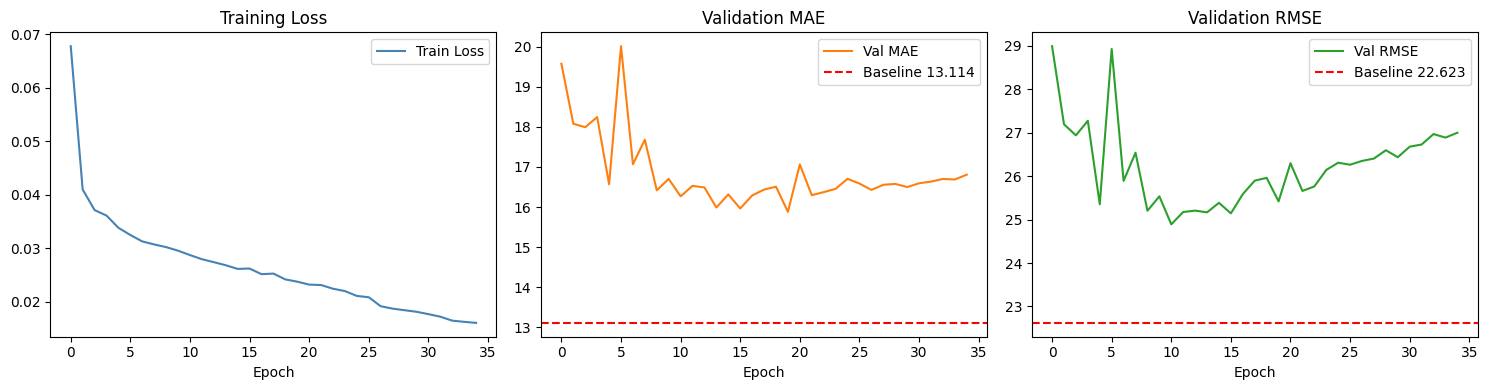

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], color='steelblue', label='Train Loss')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['val_mae'], color='tab:orange', label='Val MAE')
axes[1].axhline(13.114, color='red', ls='--', label='Baseline 13.114')
axes[1].set_title('Validation MAE'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history['val_rmse'], color='tab:green', label='Val RMSE')
axes[2].axhline(22.623, color='red', ls='--', label='Baseline 22.623')
axes[2].set_title('Validation RMSE'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [14]:
# ══════════════════════════════════════════════════
# FINAL TEST — paper-style single averaged metric
# ══════════════════════════════════════════════════
model.load_state_dict(torch.load(cfg.best_path, map_location=device))

@torch.no_grad()
def paper_style_eval(model, loader, A_dist, device, mean_flow, std_flow):
    model.eval()
    all_pred, all_true = [], []
    for x_rec, x_hour, y in loader:
        x_rec  = x_rec.to(device)
        x_hour = x_hour.to(device)
        y      = y.to(device)
        pred   = model(x_rec, x_hour, A_dist)
        pred_d = pred * std_flow[None,None,:] + mean_flow[None,None,:]
        y_d    = y    * std_flow[None,None,:] + mean_flow[None,None,:]
        all_pred.append(pred_d.cpu())
        all_true.append(y_d.cpu())

    P = torch.cat(all_pred, dim=0)   # (total, 12, 170)
    Y = torch.cat(all_true, dim=0)

    mae  = torch.abs(P - Y).mean().item()
    rmse = ((P - Y)**2).mean().sqrt().item()
    mask = Y.abs() > 10.0
    mape = (torch.abs((P[mask]-Y[mask])/(Y[mask].abs()+1.0))).mean().item()*100

    print('\n' + '='*55)
    print('  TEST RESULTS  —  averaged over all 12 steps')
    print('='*55)
    print(f'  MAE  : {mae:.3f}    baseline: 13.114   Δ={mae-13.114:+.3f}')
    print(f'  RMSE : {rmse:.3f}    baseline: 22.623   Δ={rmse-22.623:+.3f}')
    print(f'  MAPE : {mape:.3f}%   baseline:  8.471%  Δ={mape-8.471:+.3f}%')
    print('='*55)
    return mae, rmse, mape

mae, rmse, mape = paper_style_eval(
    model, dl_test, A_dist, device, mean_flow, std_flow)


  TEST RESULTS  —  averaged over all 12 steps
  MAE  : 15.164    baseline: 13.114   Δ=+2.050
  RMSE : 24.561    baseline: 22.623   Δ=+1.938
  MAPE : 8.543%   baseline:  8.471%  Δ=+0.072%


In [15]:
@torch.no_grad()
def horizon_eval(model, loader, A_dist, device, mean_flow, std_flow):
    model.eval()
    buf = {h:{'mae':[],'rmse':[],'mape':[]} for h in [2,5,11]}
    for x_rec, x_hour, y in loader:
        x_rec  = x_rec.to(device)
        x_hour = x_hour.to(device)
        y      = y.to(device)
        pred   = model(x_rec, x_hour, A_dist)
        pred_d = pred * std_flow[None,None,:] + mean_flow[None,None,:]
        y_d    = y    * std_flow[None,None,:] + mean_flow[None,None,:]
        for h in buf:
            buf[h]['mae'].append(masked_mae(pred_d[:,h,:], y_d[:,h,:]).item())
            buf[h]['rmse'].append(masked_rmse(pred_d[:,h,:], y_d[:,h,:]).item())
            buf[h]['mape'].append(masked_mape(pred_d[:,h,:], y_d[:,h,:]).item())

    print(f'{"Horizon":>14} | {"MAE":>8} | {"RMSE":>8} | {"MAPE":>9}')
    print('-'*50)
    for h, lbl in zip([2,5,11], ['3-step (15min)','6-step (30min)','12-step (60min)']):
        m = {k:np.mean(v) for k,v in buf[h].items()}
        print(f'{lbl:>14} | {m["mae"]:>8.3f} | {m["rmse"]:>8.3f} | {m["mape"]:>8.2f}%')

horizon_eval(model, dl_test, A_dist, device, mean_flow, std_flow)

       Horizon |      MAE |     RMSE |      MAPE
--------------------------------------------------
3-step (15min) |   14.348 |   21.924 |     8.06%
6-step (30min) |   15.179 |   23.453 |     8.72%
12-step (60min) |   16.455 |   25.644 |     9.23%
